# CodeLab 6. Сверточная нейронная сеть на Keras


В этом задании вам предстоит:

- изучить API Keras для создания и обучения нейросети (классификатора изображений);  
- подобрать архитектуру сети и гиперпараметры для получения accuracy > 0.8

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import models, layers


## Загрузка датасета CIFAR-10 и нормализация данных

In [28]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)

# Проверим размер входных и выходных векторов.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

c:\Users\Denis\Documents\PythonScripts\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000, 1)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000, 1)


In [29]:
# Для сверточных сетей оставляем shape=(32,32,3), изменяем только формат данных uint8 -> fp64
X_train = X_train.astype(np.float64)
X_test = X_test.astype(np.float64)
y_train = y_train.flatten()
y_test = y_test.flatten()
# Проверим размер полученных данных
print('Training data shape: ', X_train.shape)
print('Test data shape: ', X_test.shape)
print('Training label shape: ', y_train.shape)
print('Test label shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Test data shape:  (10000, 32, 32, 3)
Training label shape:  (50000,)
Test label shape:  (10000,)


In [30]:
# Разделим данные на выборки train, val, test

num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 16

# Для валидации используем подвыборку train
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# На остальных данных из train будем тренировать модель
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# Чтобы ускорить разработку, создадим также небольшую dev выборку 
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# Для тестирования используем оригинальную выборку test
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 32, 32, 3)
Train labels shape:  (49000,)
Validation data shape:  (1000, 32, 32, 3)
Validation labels shape:  (1000,)
Test data shape:  (1000, 32, 32, 3)
Test labels shape:  (1000,)


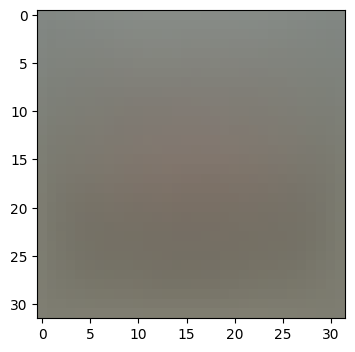

(49000, 32, 32, 3) (1000, 32, 32, 3) (1000, 32, 32, 3) (16, 32, 32, 3)


In [31]:
# Нормализуем значения яркости пикселей 
mean_image = np.mean(X_train, axis=0)

# визуализируем среднюю яркость
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) 
plt.show()

# Вычтем средние значения яркости
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image


print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

## LeNet architecture

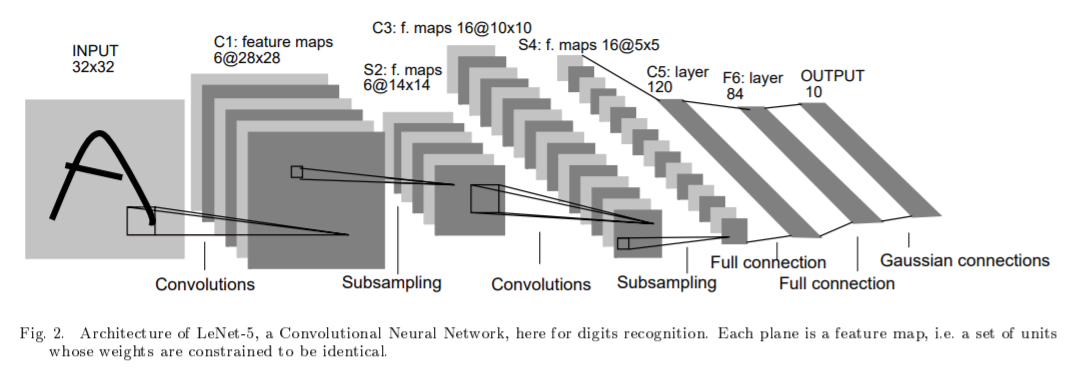

In [32]:
# Create LeNet instance
IMAGE_SHAPE = (32, 32, 3)
NUM_CLASSES = 10

lenet = tf.keras.models.Sequential()
lenet.add(tf.keras.layers.Input(shape=IMAGE_SHAPE))
lenet.add(tf.keras.layers.Conv2D(6, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding="same"))
lenet.add(tf.keras.layers.AveragePooling2D(pool_size=(2, 2), strides=(1, 1), padding='valid'))
lenet.add(tf.keras.layers.Conv2D(6, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding='valid'))
lenet.add(tf.keras.layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))
lenet.add(tf.keras.layers.Conv2D(16, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding='valid'))
lenet.add(tf.keras.layers.Flatten())
lenet.add(tf.keras.layers.Dense(84, activation='tanh'))
lenet.add(tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'))    
lenet.compile(loss=tf.keras.losses.categorical_crossentropy, optimizer='SGD')

## Переобучим LeNet на малой выборке

In [33]:
# transform y indexes to sparse representation: [2] -> [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
y_dev_sparse = tf.keras.utils.to_categorical(y_dev, num_classes=NUM_CLASSES)

# Check initial loss and overfitting model with small dev dataset
hist = lenet.fit(X_dev, y_dev_sparse, batch_size=32, epochs=10)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - loss: 2.5073
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 2.2352
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 2.0324
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 1.8571
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 1.6375
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 1.5258
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 1.3558
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 1.2413
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 1.1807
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 1.0435


## Обучение LeNet на датасете Cifar10 c гиперпараметрами по умолчанию

In [34]:
BS = 64
LR = 1e-4
EPOCHS = 8

optimizer = tf.keras.optimizers.Adam(learning_rate=LR)
lenet.compile(loss=tf.keras.losses.categorical_crossentropy, optimizer=optimizer, metrics=['accuracy'])

y_train_sparse = tf.keras.utils.to_categorical(y_train, num_classes=NUM_CLASSES)
history = lenet.fit(X_train, y_train_sparse, validation_split=0.2, batch_size=BS, epochs=EPOCHS)

Epoch 1/8
613/613 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3334 - loss: 1.8723 - val_accuracy: 0.3701 - val_loss: 1.7886
Epoch 2/8
613/613 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4033 - loss: 1.7191 - val_accuracy: 0.3998 - val_loss: 1.7194
Epoch 3/8
613/613 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4284 - loss: 1.6561 - val_accuracy: 0.4143 - val_loss: 1.6792
Epoch 4/8
613/613 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4433 - loss: 1.6147 - val_accuracy: 0.4257 - val_loss: 1.6560
Epoch 5/8
613/613 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4560 - loss: 1.5809 - val_accuracy: 0.4310 - val_loss: 1.6366
Epoch 6/8
613/613 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4637 - loss: 1.5538 - val_accuracy: 0.4366 - val_loss: 1.6149
Epoch 7/8
613/613 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4736 - loss: 1.5299 - val_accuracy: 0.4449 - val_loss: 1.5957
Epoch 8/8
613/613 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4809 - loss: 1.5077 - val_accuracy: 0.4488 - v

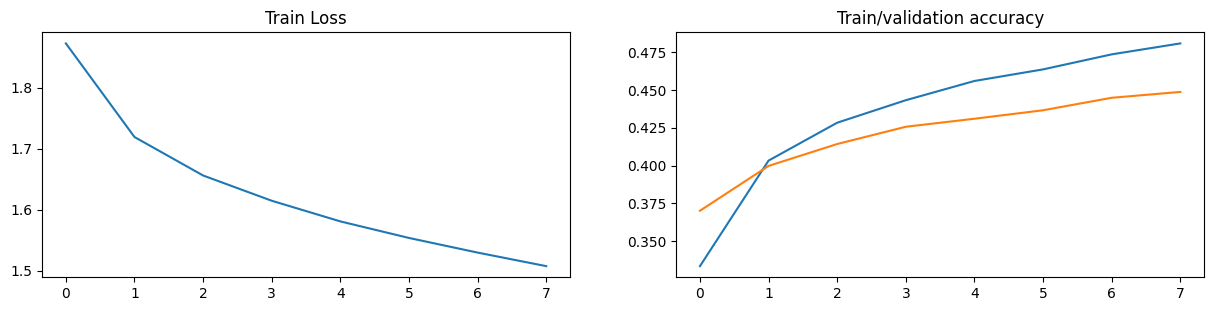

In [35]:
plt.figure(figsize=(15, 7))
plt.subplot(221)
plt.title("Train Loss")
plt.plot(history.history['loss'])
plt.subplot(222)
plt.title("Train/validation accuracy")
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

## Подбор архитектуры собственной сети и гиперпараметров обучения
Как видно из графиков, модель переобучилась. Поэкспериментируйте с гиперпараметрами и архитектурой, чтобы получить точность на тесте больше 80%

In [ ]:
# Experiment here!
class YourNameNet(models.Sequential):
    def __init__(self, input_shape, nb_classes):
        super().__init__()

        # Блок 1
        self.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                               input_shape=input_shape))
        self.add(layers.BatchNormalization())
        self.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
        self.add(layers.BatchNormalization())
        self.add(layers.MaxPooling2D(pool_size=(2, 2)))
        self.add(layers.Dropout(0.25))

        # Блок 2
        self.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
        self.add(layers.BatchNormalization())
        self.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
        self.add(layers.BatchNormalization())
        self.add(layers.MaxPooling2D(pool_size=(2, 2)))
        self.add(layers.Dropout(0.25))

        # Блок 3
        self.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
        self.add(layers.BatchNormalization())
        self.add(layers.MaxPooling2D(pool_size=(2, 2)))
        self.add(layers.Dropout(0.25))

        # Классификатор
        self.add(layers.Flatten())
        self.add(layers.Dense(256, activation='relu'))
        self.add(layers.BatchNormalization())
        self.add(layers.Dropout(0.5))
        self.add(layers.Dense(nb_classes, activation='softmax'))

        

your_net = YourNameNet(IMAGE_SHAPE, NUM_CLASSES)

c:\Users\Denis\Documents\PythonScripts\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
# Обучение YourNameNet
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
your_net.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=optimizer,
    metrics=['accuracy']
)

y_train_sparse = keras.utils.to_categorical(y_train, num_classes=NUM_CLASSES)

history = your_net.fit(
    X_train, y_train_sparse,
    validation_split=0.2,
    batch_size=64,
    epochs=30
)

Epoch 1/30
613/613 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - accuracy: 0.4388 - loss: 1.6694 - val_accuracy: 0.5340 - val_loss: 1.3600
Epoch 2/30
613/613 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.5873 - loss: 1.1576 - val_accuracy: 0.6398 - val_loss: 1.0456
Epoch 3/30
613/613 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.6554 - loss: 0.9742 - val_accuracy: 0.6932 - val_loss: 0.8904
Epoch 4/30
613/613 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.6979 - loss: 0.8606 - val_accuracy: 0.7095 - val_loss: 0.8395
Epoch 5/30
613/613 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.7232 - loss: 0.7884 - val_accuracy: 0.7392 - val_loss: 0.7492
Epoch 6/30
613/613 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.7434 - loss: 0.7336 - val_accuracy: 0.7418 - val_loss: 0.7670
Epoch 7/30
613/613 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.7617 - loss: 0.6818 - val_accuracy: 0.7767 - val_loss: 0.6419
Epoch 8/30
613/613 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.7701 - loss: 0.6528 - 

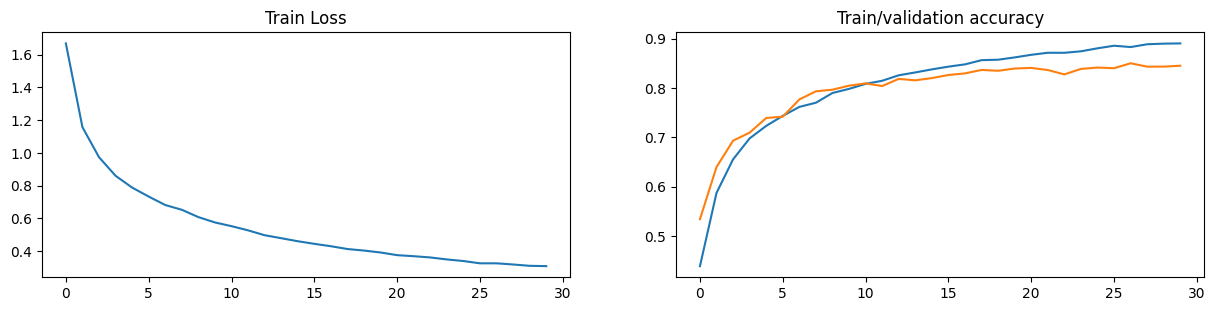

In [45]:
plt.figure(figsize=(15, 7))
plt.subplot(221)
plt.title("Train Loss")
plt.plot(history.history['loss'])
plt.subplot(222)
plt.title("Train/validation accuracy")
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [44]:
def multiclass_accuracy(y_pred, y_true):
  return np.mean(np.equal(y_true, np.argmax(y_pred, axis=1)))


y_test_pred = your_net.predict(X_test)
test_accuracy = multiclass_accuracy(y_test_pred, y_test)

print('YourNet test set accuracy: %f' % (test_accuracy, ))
assert test_accuracy > 0.8

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
YourNet test set accuracy: 0.853000


In [46]:
your_net.save('yournet_cifar10.h5')  